In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns


In [5]:
df = pd.read_excel(r'E:\projects\Customer_Churn_Classification\Bank_Churn_Modelling.xlsx')

# Data preprocessing & EDA

In [6]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

In [8]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
df.shape

(10000, 11)

In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [11]:
 df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [12]:
df.describe(include='O')

,Geography,Gender
count,10000,10000
unique,3,2
top,France,Male
freq,5014,5457


In [13]:
df.Geography.value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [14]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [15]:
df.duplicated().sum()

0

In [16]:
df.Exited.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

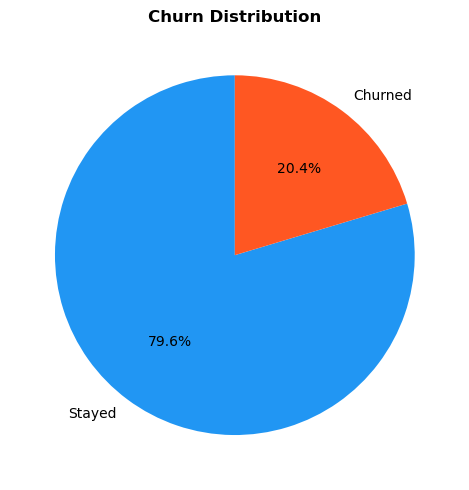

In [17]:
df['Exited'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(5,5) , labels=['Stayed','Churned'], colors=['#2196F3','#FF5722'], startangle=90)
plt.title('Churn Distribution', fontsize=12, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [18]:
cato= df.select_dtypes(include='O').columns
num = df.select_dtypes(include=np.number).columns
print(f'categorical columns: {cato}')
print(f'numerical columns: {num}')

categorical columns: Index(['Geography', 'Gender'], dtype='object')
numerical columns: Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


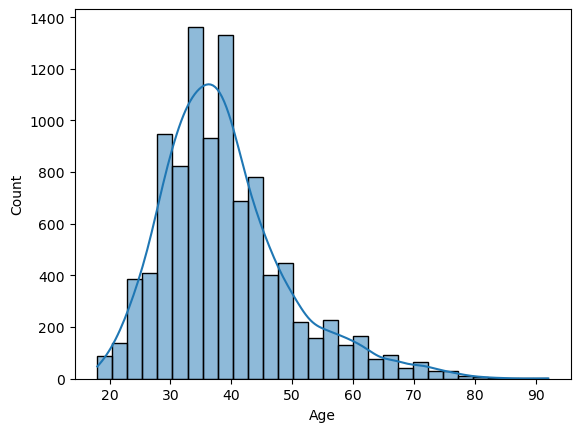

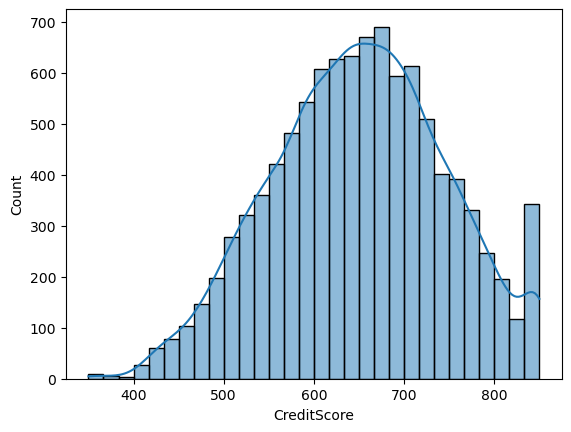

In [19]:
for column in ['Age', 'CreditScore']:
    
    sns.histplot(data=df, x=column, kde=True, bins=30)
    plt.show()

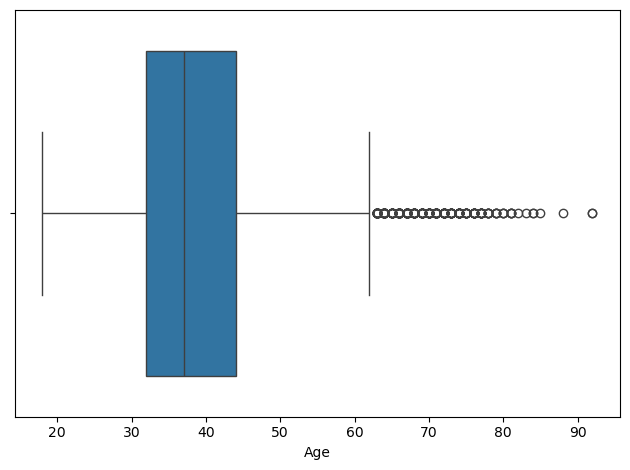

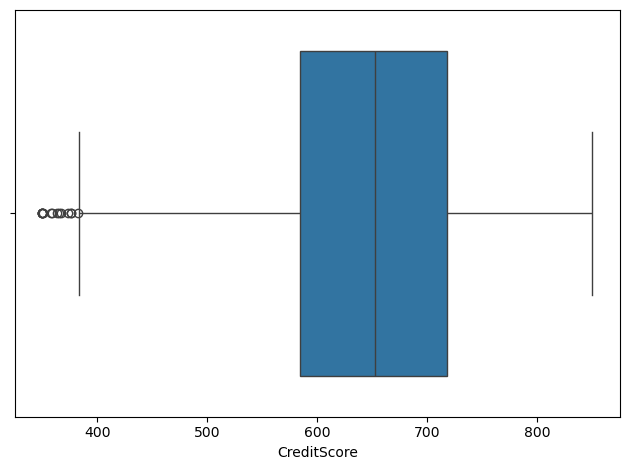

In [20]:
for column in ['Age', 'CreditScore']:  
    sns.boxplot(data=df, x=column)
    plt.tight_layout()
    plt.show()

In [21]:
df.corr( numeric_only=True)['Exited']

CreditScore       -0.027094
Age                0.285323
Tenure            -0.014001
Balance            0.118533
NumOfProducts     -0.047820
HasCrCard         -0.007138
IsActiveMember    -0.156128
EstimatedSalary    0.012097
Exited             1.000000
Name: Exited, dtype: float64

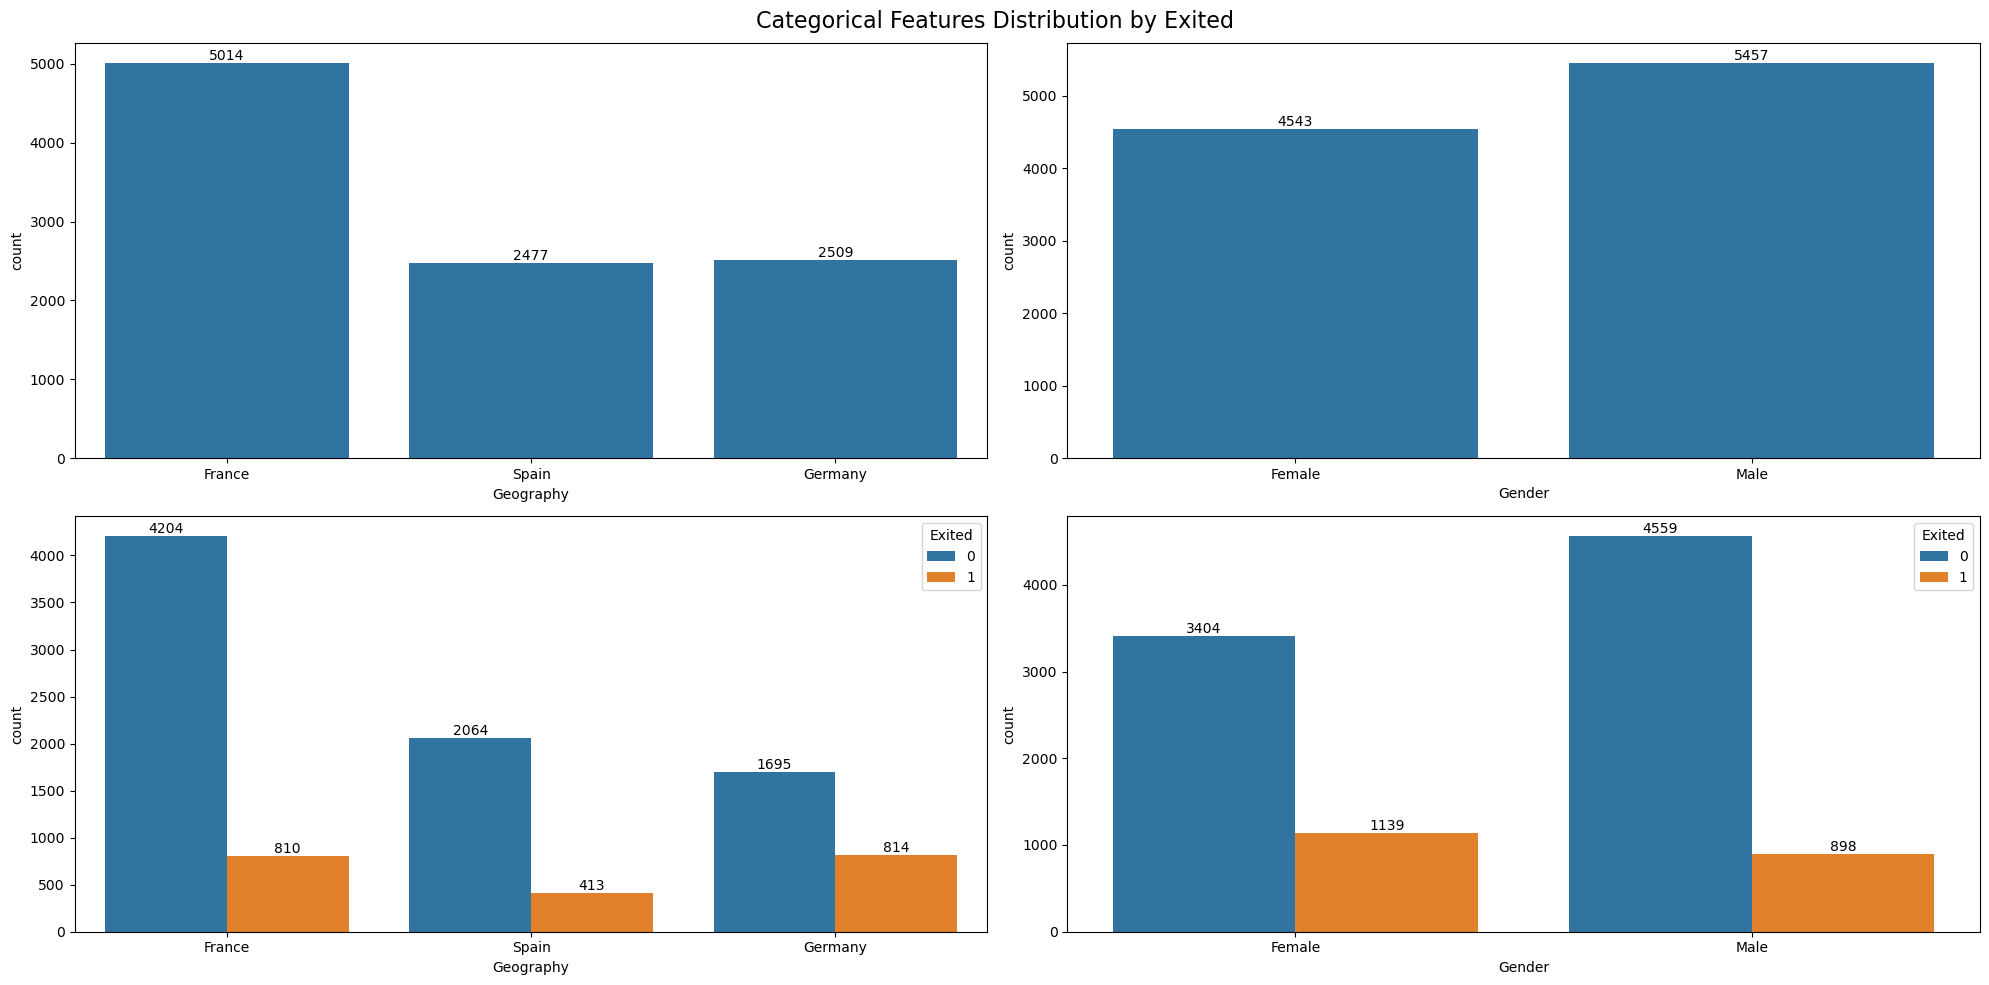

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

fig.suptitle('Categorical Features Distribution by Exited', fontsize=16)


for i,x in enumerate(cato):
    ax = sns.countplot(x=x, data=df, ax=axes[i//2, i%2])
    for x in ax.containers:
      ax.bar_label(x)

for i,x in enumerate(cato):
    ax = sns.countplot(x=x, hue='Exited', data=df, ax=axes[i//2+1, i%2])
    for x in ax.containers:
      ax.bar_label(x)

plt.tight_layout()
plt.show()

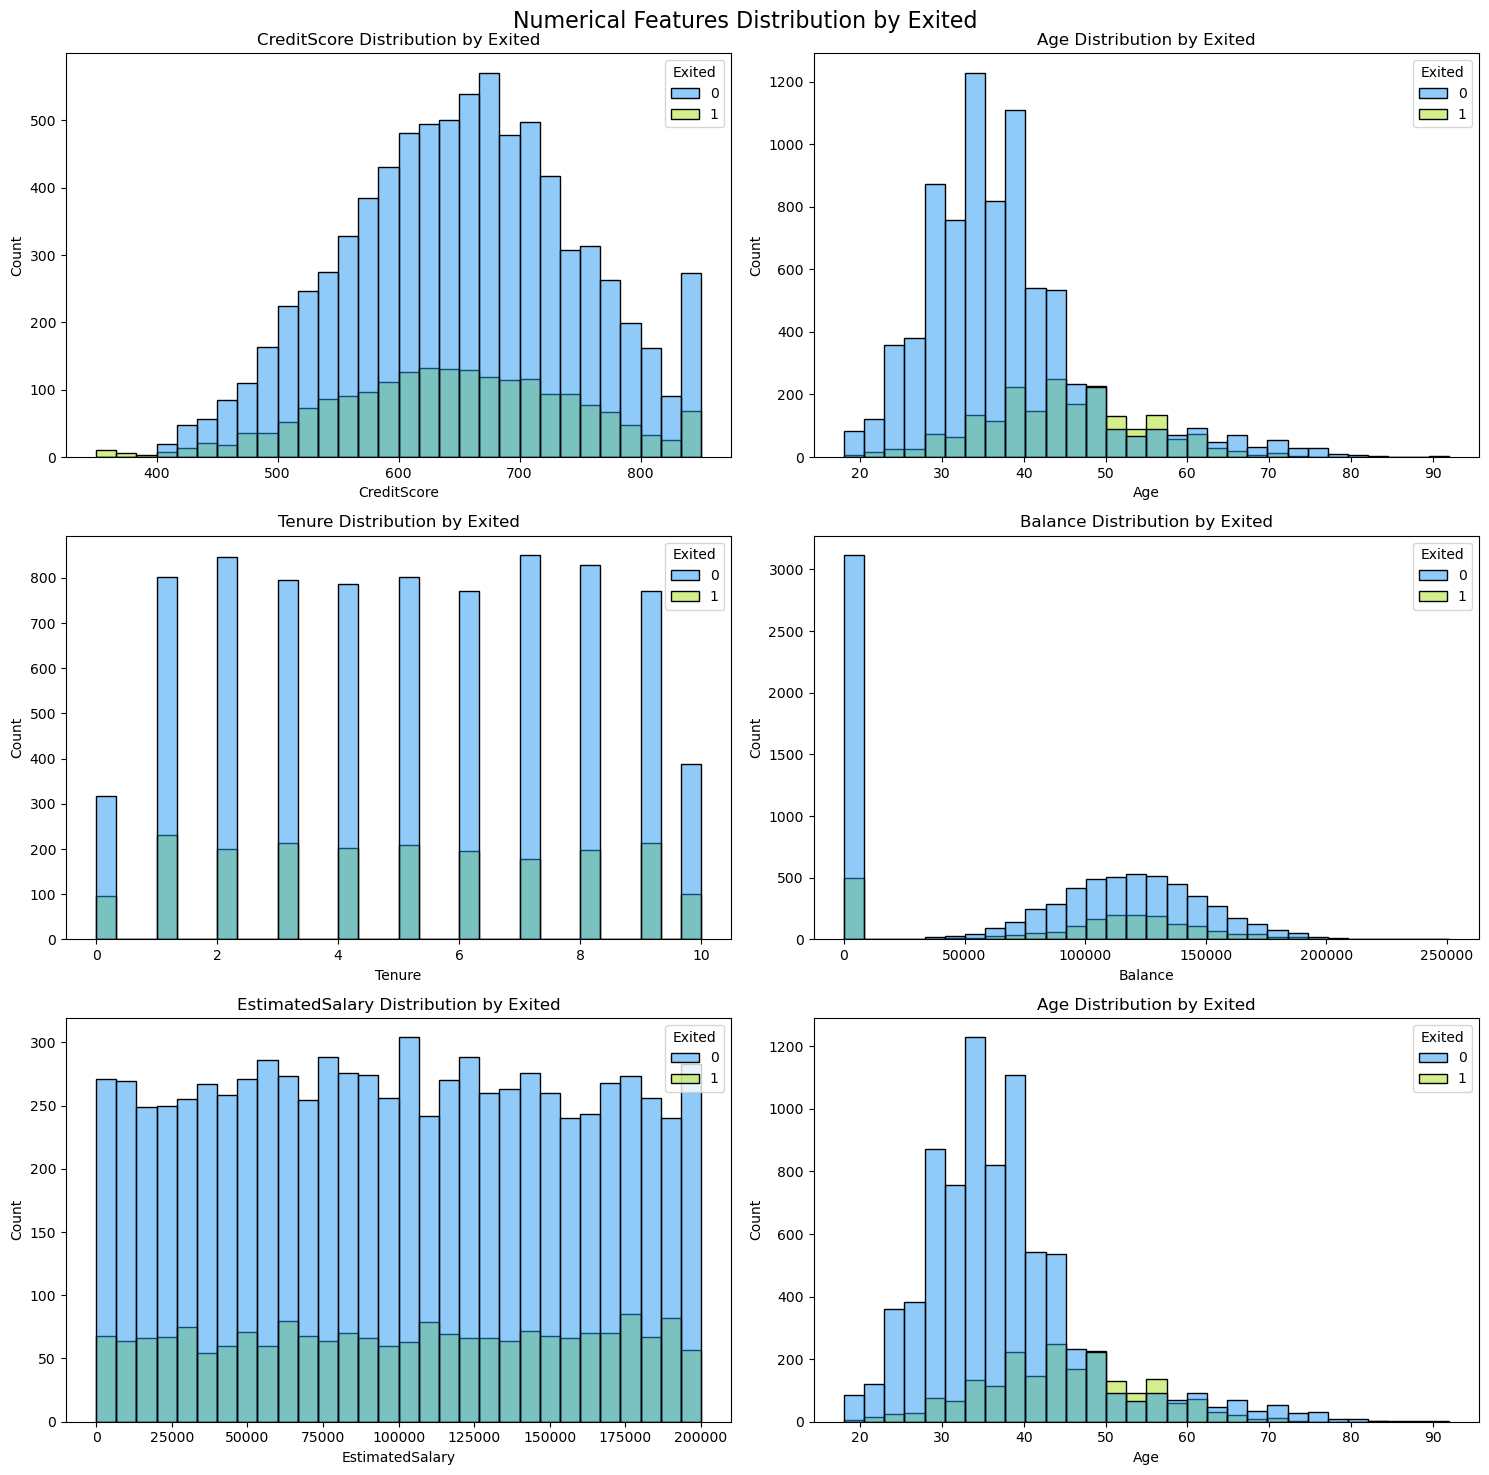

In [23]:
features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary','Age']

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
plt.suptitle('Numerical Features Distribution by Exited', fontsize=16)
axes = axes.flatten()
for i, x in enumerate(features):
    sns.histplot(data=df, x=x, hue='Exited', bins=30,  ax=axes[i], palette=['#2196F3',"#A6E11A"],)
    axes[i].set_title(f'{x} Distribution by Exited')
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


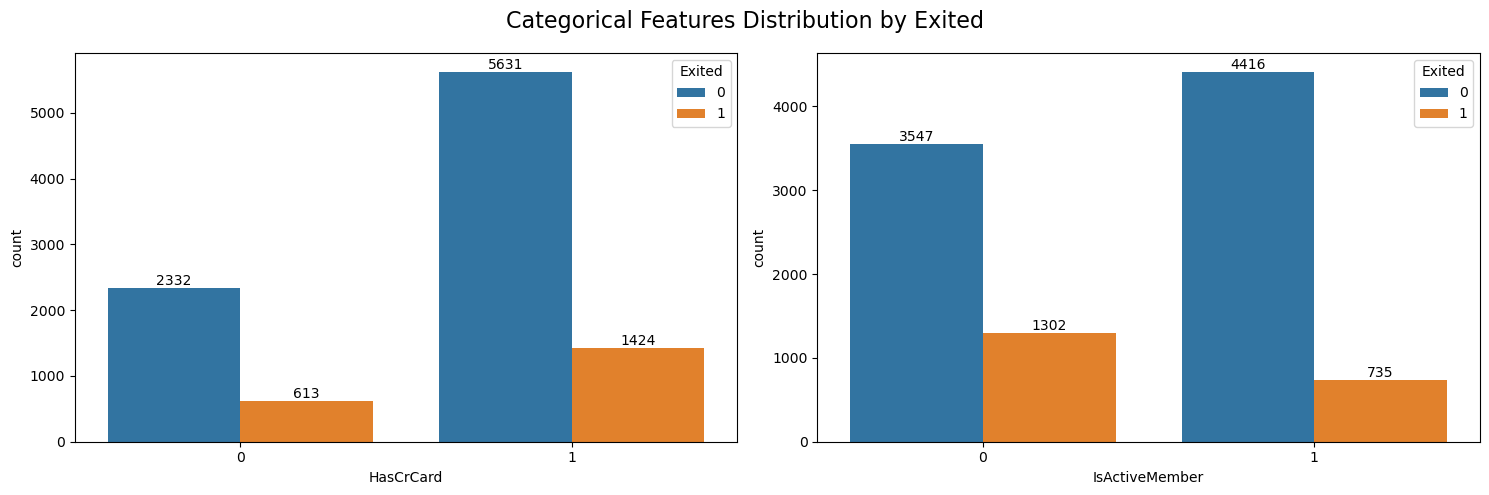

In [24]:
features = ['HasCrCard','IsActiveMember',]



fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fig.suptitle('Categorical Features Distribution by Exited', fontsize=16)

for i,x in enumerate(features):
    ax = sns.countplot(x=x, hue='Exited', data=df, ax=axes[i])
    for x in ax.containers:
      ax.bar_label(x)

plt.tight_layout()
plt.show()

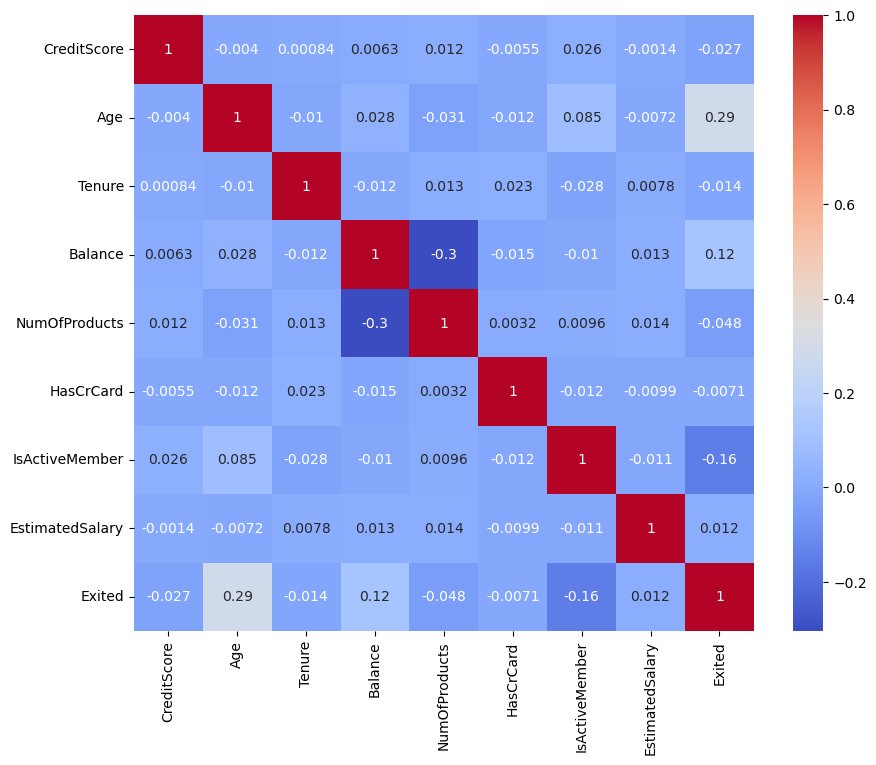

In [25]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.show()

In [26]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_boundary = Q1 - 1.5 * IQR
upper_boundary = Q3 + 1.5 * IQR


df['Age'] = df['Age'].clip(lower=lower_boundary, upper=upper_boundary)

print(f"Lower Boundary: {lower_boundary}")
print(f"Upper Boundary: {upper_boundary}")

Lower Boundary: 14.0
Upper Boundary: 62.0


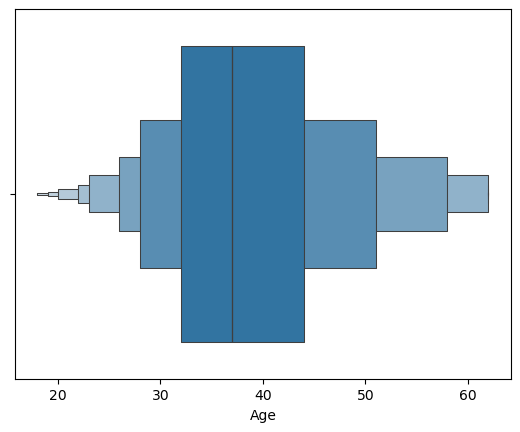

In [27]:
sns.boxenplot(data=df, x='Age')
plt.show()

In [28]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

# Spliting the data

In [29]:
X = df.drop('Exited', axis=1)
y = df['Exited']


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y,test_size=0.30,random_state=42,stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp,test_size=0.50,random_state=42,stratify=y_temp)

In [31]:
categorical_features = X.select_dtypes(include='O').columns
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
        'EstimatedSalary']

In [32]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features)
]).set_output(transform='pandas')

# Train
X_train_preprocessed = preprocessor.fit_transform(X_train)

# Validation
X_val_preprocessed = preprocessor.transform(X_val)

# Test
X_test_preprocessed = preprocessor.transform(X_test)

In [33]:
X_train_preprocessed.head()

,num__CreditScore,num__Age,num__Tenure,num__Balance,num__NumOfProducts,num__EstimatedSalary,cat__Geography_Germany,cat__Geography_Spain,cat__Gender_Male
9136,-0.575582,-1.913263,-0.349474,0.312906,-0.912483,1.362512,0.0,0.0,1.0
6410,0.398182,2.379937,-1.386929,-1.223574,0.799493,1.515472,0.0,1.0,0.0
2607,1.693082,-0.788854,-1.386929,0.682321,-0.912483,0.038955,0.0,0.0,1.0
3201,0.740036,-1.913263,0.342162,-1.223574,0.799493,1.671444,0.0,0.0,1.0
3330,0.905783,-2.117701,-0.349474,-1.223574,0.799493,-0.899384,0.0,0.0,1.0


#Applying SMOTE

In [34]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_preprocessed, y_train)

# LogisticRegression

In [35]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_preprocessed, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [36]:
print('Train Accuracy:', model.score(X_train_preprocessed, y_train))
print('Validation Accuracy:', model.score(X_val_preprocessed, y_val))

Train Accuracy: 0.7978571428571428
Validation Accuracy: 0.8113333333333334


In [37]:
y_val_pred = model.predict(X_val_preprocessed)

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

[[1161   33]
 [ 250   56]]
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1194
           1       0.63      0.18      0.28       306

    accuracy                           0.81      1500
   macro avg       0.73      0.58      0.59      1500
weighted avg       0.78      0.81      0.77      1500



# Models

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Logistic RegressionW': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'SVM': SVC(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    
    clf_pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('classifier', model)
    ])
    
    clf_pipeline.fit(X_train, y_train)
    
  
    score = clf_pipeline.score(X_val, y_val)
    
    results[name] = score
    
    print(f"{name} accuracy: {score:.3f}")

Logistic Regression accuracy: 0.811
Logistic RegressionW accuracy: 0.722
SVM accuracy: 0.849
Random Forest accuracy: 0.856
KNN accuracy: 0.830


# Xgboost

In [39]:
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)


xgb_model.fit(X_train_preprocessed, y_train)

y_val_pred = xgb_model.predict(X_val_preprocessed)
y_val_prob = xgb_model.predict_proba(X_val_preprocessed)[:, 1]

print("=== Validation ===")
print(classification_report(y_val, y_val_pred))
print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.2%}")
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))

=== Validation ===
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1194
           1       0.77      0.46      0.57       306

    accuracy                           0.86      1500
   macro avg       0.82      0.71      0.75      1500
weighted avg       0.85      0.86      0.85      1500

Accuracy: 86.13%
ROC-AUC: 0.8674308360976998


In [40]:
y_test_pred = xgb_model.predict(X_test_preprocessed)
y_test_prob = xgb_model.predict_proba(X_test_preprocessed)[:, 1]

print("\n=== Final Test ===")
print(classification_report(y_test, y_test_pred))
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_test_pred):.2%}")
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob))


=== Final Test ===
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1195
           1       0.72      0.44      0.55       305

    accuracy                           0.85      1500
   macro avg       0.79      0.70      0.73      1500
weighted avg       0.84      0.85      0.84      1500

XGBoost Accuracy: 85.13%
ROC-AUC: 0.8471225735647163


XGBoost achieved the best final test performance with 85.13% accuracy and ROC-AUC of 0.847. For the churn class, the model achieved precision of 0.72, recall of 0.44, and F1-score of 0.55, indicating reliable churn predictions with some missed churn cases.

In [41]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers


In [42]:
X_train_preprocessed.shape

(7000, 9)

In [43]:


model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_preprocessed.shape[1],),
                        kernel_regularizer=regularizers.L2(0.01)),
  
     layers.Dropout(0.2),
     layers.BatchNormalization(),
    keras.layers.Dense(64, activation='relu'),
     layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])


c:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 9,857 (38.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [45]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

In [46]:
history = model.fit(X_train_preprocessed, y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7895 - loss: 0.6206 - val_accuracy: 0.8214 - val_loss: 0.5887
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8171 - loss: 0.5163 - val_accuracy: 0.8343 - val_loss: 0.4742
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8289 - loss: 0.4688 - val_accuracy: 0.8379 - val_loss: 0.4394
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8304 - loss: 0.4490 - val_accuracy: 0.8386 - val_loss: 0.4199
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8330 - loss: 0.4306 - val_accuracy: 0.8414 - val_loss: 0.4040
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8341 - loss: 0.4133 - val_accuracy: 0.8393 - val_loss: 0.3974
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8345 - loss: 0.4056 - val_accuracy: 0.8393 - val_loss: 0.3918
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8375 - loss: 0.4015 - val_accu

In [47]:
loss, acc = model.evaluate(X_val_preprocessed, y_val, verbose=0)
print(f"Validation Loss: {loss:.4f}, Validation Accuracy: {acc:.4f}")


Validation Loss: 0.3597, Validation Accuracy: 0.8547


In [48]:
y_pred = model.predict(X_test_preprocessed)
print(y_pred[0:10])

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[0.29331937]
 [0.00839372]
 [0.01986713]
 [0.07130671]
 [0.17345126]
 [0.03862614]
 [0.04394052]
 [0.09621647]
 [0.50664335]
 [0.7242732 ]]


In [49]:
y_test[0:10]

9161    0
8692    0
4616    0
5818    0
9093    0
6345    0
5587    0
1606    0
8379    1
1305    1
Name: Exited, dtype: int64

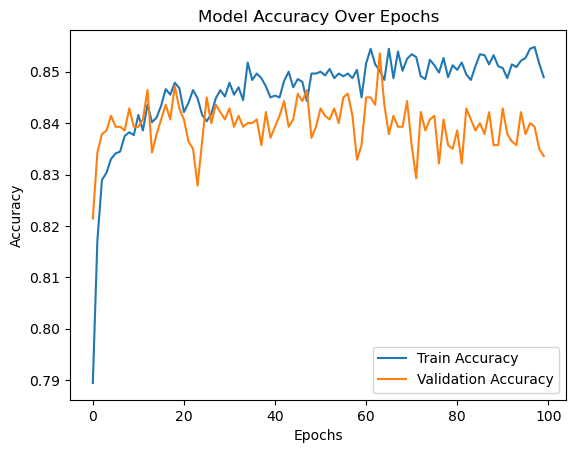

In [50]:

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [51]:
print(confusion_matrix(y_val, y_val_pred))


[[1152   42]
 [ 166  140]]


In [52]:
print(classification_report(y_val, y_val_pred))


              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1194
           1       0.77      0.46      0.57       306

    accuracy                           0.86      1500
   macro avg       0.82      0.71      0.75      1500
weighted avg       0.85      0.86      0.85      1500



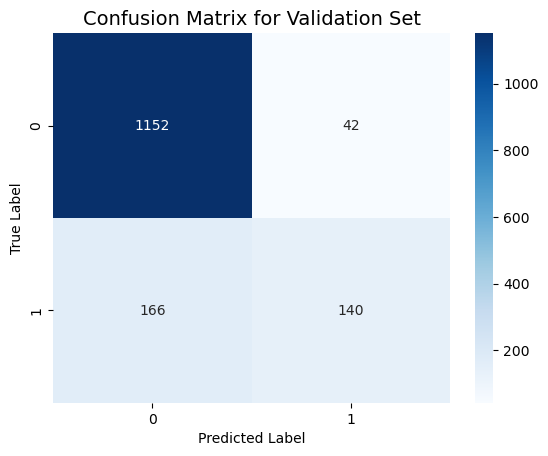

In [53]:
sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Validation Set', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()